# Fase 1: Análisis y Preprocesamiento de Datos (Múltiples Datasets)

## 1. Definición del Objetivo
El objetivo de este proyecto es construir y entrenar una Red Neuronal Convolucional (CNN) capaz de clasificar correctamente imágenes de manos que representan los dígitos del 0 al 9 en lenguaje de señas. 

## 2. Recolección y Consolidación de Datos
Para robustecer el modelo, hemos unificado 4 datasets distintos provenientes de Kaggle. El flujo de trabajo descarga un archivo comprimido con todos los datos en bruto organizados en carpetas y los extrae en el directorio local para su estandarización.

In [1]:
import os
import zipfile

ruta_zip = '../dataset/MegaDataset_SignLanguage.zip'
ruta_extraccion = '../dataset/datos_brutos/'

os.makedirs('../dataset', exist_ok=True)

if not os.path.exists(ruta_zip):
    print("Descargando el dataset unificado desde Google Drive...")
    
    id_archivo = '1maeZ7Ch9mPWp-JaShXXwlvUYmRfBclZ4'
    
    !gdown "https://drive.google.com/uc?id={id_archivo}" -O {ruta_zip}
    
    print("¡Descarga completada!")
else:
    print("El archivo .zip ya está en el equipo. Saltando descarga.")

# 3. Descomprimir con la librería nativa de Python
if not os.path.exists(ruta_extraccion):
    print("Descomprimiendo imágenes, por favor espere...")
    try:
        with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
            zip_ref.extractall(ruta_extraccion)
        print(f"¡Todo listo! Imágenes extraídas en: {ruta_extraccion}")
    except Exception as e:
        print(f"Error al descomprimir: {e}")
else:
    print(f"La carpeta ya estaba lista en: {ruta_extraccion}")

El archivo .zip ya está en el equipo. Saltando descarga.
La carpeta ya estaba lista en: ../dataset/datos_brutos/


## 3. Estandarización Universal (El Embudo)
Dado que los 4 datasets vienen con resoluciones, canales de color y estructuras distintas, utilizaremos OpenCV para leer cada imagen dinámicamente. El programa buscará cualquier carpeta nombrada del `0` al `9`, convertirá las imágenes a escala de grises (1 canal) y las redimensionará exactamente a `64x64` píxeles.

In [2]:
import numpy as np
import cv2
import os

def procesar_datasets(ruta_base):
    imagenes = []
    etiquetas = []
    
    ruta_npy_x = None
    ruta_npy_y = None
    
    for raiz, directorios, archivos in os.walk(ruta_base):
        if 'X.npy' in archivos and 'Y.npy' in archivos:
            ruta_npy_x = os.path.join(raiz, 'X.npy')
            ruta_npy_y = os.path.join(raiz, 'Y.npy')
            break
            
    if ruta_npy_x and ruta_npy_y:
        print(f"Procesando Dataset 1 (.npy encontrados en {ruta_npy_x})...")
        X_npy = np.load(ruta_npy_x)
        Y_npy = np.load(ruta_npy_y)
        
        orden_clases = np.array([9, 0, 7, 6, 1, 8, 4, 3, 2, 5])
        etiquetas_reales = orden_clases[np.argmax(Y_npy, axis=1)]
        
        for i in range(len(X_npy)):
            img = X_npy[i]
            if img.shape[:2] != (64, 64):
                img = cv2.resize(img, (64, 64))
                
            if np.max(img) > 1.5:
                img = img.astype('float32') / 255.0
                
            imagenes.append(img.reshape(64, 64, 1))
            etiquetas.append(etiquetas_reales[i])

    print("Escaneando directorios en busca de imágenes sueltas...")
    
    for raiz, directorios, archivos in os.walk(ruta_base):
        nombre_carpeta = os.path.basename(raiz)
        clase_real = None
        
        if nombre_carpeta.isdigit() and 0 <= int(nombre_carpeta) <= 9:
            clase_real = int(nombre_carpeta)
            
        elif nombre_carpeta.startswith('numbers_'):
            try:
                num = int(nombre_carpeta.split('_')[1])
                if 0 <= num <= 9:
                    clase_real = num
            except:
                pass
                
        if clase_real is not None:
            for nombre_archivo in archivos:
                ext = nombre_archivo.lower()
                if not (ext.endswith('.jpg') or ext.endswith('.png') or ext.endswith('.jpeg')):
                    continue
                    
                ruta_imagen = os.path.join(raiz, nombre_archivo)
                img = cv2.imread(ruta_imagen)
                
                if img is None:
                    continue
                    
                img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
                img_resized = cv2.resize(img_gray, (64, 64))
                img_norm = img_resized.astype('float32') / 255.0
                
                imagenes.append(img_norm.reshape(64, 64, 1))
                etiquetas.append(clase_real)

    if len(imagenes) == 0:
        raise ValueError("CRÍTICO: No se procesó ninguna imagen. Verifica que los archivos existan.")

    X_total = np.array(imagenes, dtype='float32')
    Y_total = np.array(etiquetas, dtype=int)
    Y_onehot = np.eye(10)[Y_total]
    
    return X_total, Y_onehot, Y_total

X, Y, Y_reales = procesar_datasets(ruta_extraccion)

print(f"\n ¡MEGA-DATASET CREADO CON ÉXITO!")
print(f"Dimensiones de X (Imágenes): {X.shape}")
print(f"Dimensiones de Y (Etiquetas One-Hot): {Y.shape}")

Procesando Dataset 1 (.npy encontrados en ../dataset/datos_brutos/datasets\Sign-language-digits-dataset\X.npy)...
Escaneando directorios en busca de imágenes sueltas...

 ¡MEGA-DATASET CREADO CON ÉXITO!
Dimensiones de X (Imágenes): (18026, 64, 64, 1)
Dimensiones de Y (Etiquetas One-Hot): (18026, 10)


## 4. Análisis Exploratorio de Datos (EDA)
Al unir múltiples fuentes de datos, es crucial revisar cómo quedó el balance final de nuestras clases, ya que algunos datasets carecen de ciertos números (por ejemplo, el dígito 0).

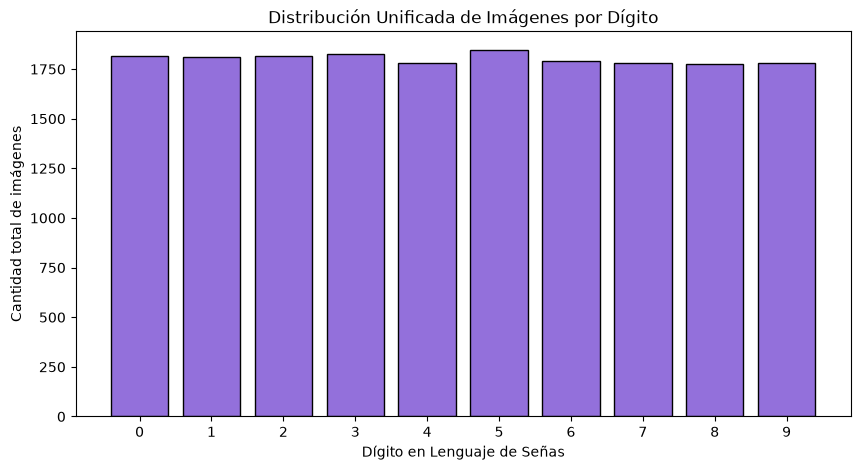

--- Conteo exacto por clase ---
Dígito 0: 1815 imágenes
Dígito 1: 1810 imágenes
Dígito 2: 1816 imágenes
Dígito 3: 1828 imágenes
Dígito 4: 1783 imágenes
Dígito 5: 1847 imágenes
Dígito 6: 1791 imágenes
Dígito 7: 1780 imágenes
Dígito 8: 1776 imágenes
Dígito 9: 1780 imágenes


In [3]:
import matplotlib.pyplot as plt

clases, conteo = np.unique(Y_reales, return_counts=True)

plt.figure(figsize=(10, 5))
plt.bar(clases, conteo, color='mediumpurple', edgecolor='black')
plt.title('Distribución Unificada de Imágenes por Dígito')
plt.xlabel('Dígito en Lenguaje de Señas')
plt.ylabel('Cantidad total de imágenes')
plt.xticks(clases) 
plt.show()

print("--- Conteo exacto por clase ---")
for clase, cantidad in zip(clases, conteo):
    print(f"Dígito {clase}: {cantidad} imágenes")

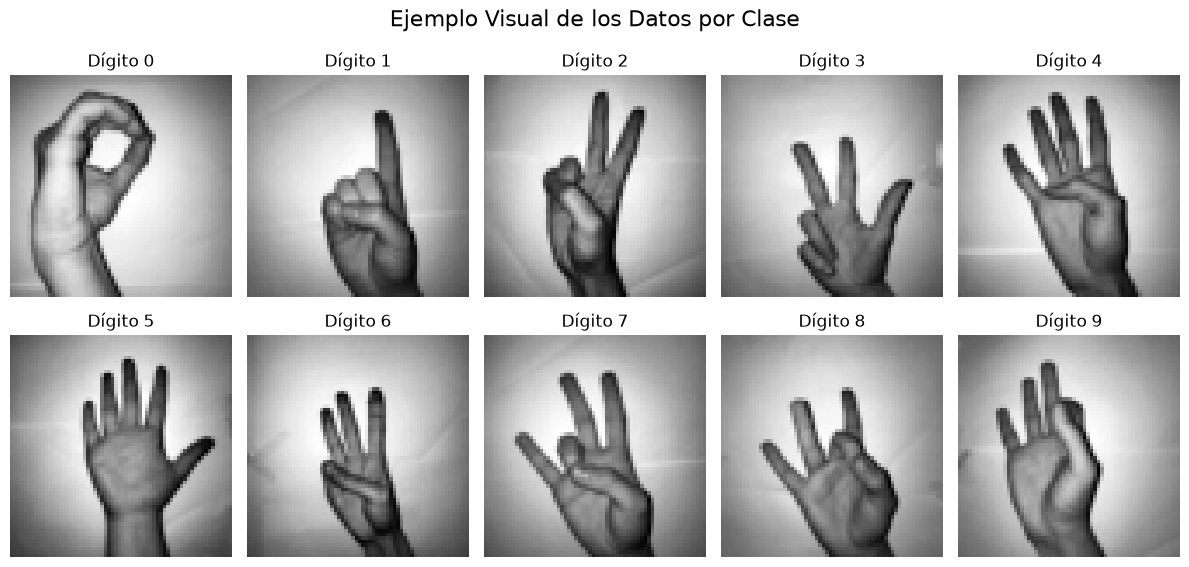

In [4]:
plt.figure(figsize=(12, 6))
for i in range(10):
    # Buscar la primera ocurrencia de cada clase (0 al 9)
    idx = np.where(Y_reales == i)[0][0]
    # Seleccionar la imagen y darle formato 2D para graficarla
    imagen = X[idx].reshape(64, 64)
    
    # Crear un subplot en una cuadrícula de 2 filas y 5 columnas
    plt.subplot(2, 5, i + 1)
    plt.imshow(imagen, cmap='gray')
    plt.title(f'Dígito {i}')
    plt.axis('off')
    
plt.suptitle('Ejemplo Visual de los Datos por Clase', fontsize=16)
plt.tight_layout()
plt.show()

## 5. División de Datos y Data Augmentation
Dividimos de forma aleatoria todo el dataset unificado y aplicamos transformaciones para robustecer el entrenamiento de la red convolucional.

In [5]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

X_normalizado = X.copy()

X_train, X_temp, Y_train, Y_temp = train_test_split(X_normalizado, Y, test_size=0.30, random_state=42)

X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.50, random_state=42)

print("--- Resumen de la División de Datos ---")
print(f"Datos de Entrenamiento: {X_train.shape[0]} imágenes")
print(f"Datos de Validación: {X_val.shape[0]} imágenes")
print(f"Datos de Prueba: {X_test.shape[0]} imágenes")
print(f"Valor máximo de un píxel (Seguridad): {np.max(X_train)}")

datagen = ImageDataGenerator(
    rotation_range=15,       
    zoom_range=0.15,         
    width_shift_range=0.1,   
    height_shift_range=0.1,  
)
datagen.fit(X_train)
print("\nConfigurador de Data Augmentation listo.")

ruta_guardado = '../dataset/datos_procesados/'
os.makedirs(ruta_guardado, exist_ok=True)

np.save(os.path.join(ruta_guardado, 'X_train.npy'), X_train)
np.save(os.path.join(ruta_guardado, 'X_val.npy'),   X_val)
np.save(os.path.join(ruta_guardado, 'X_test.npy'),  X_test)
np.save(os.path.join(ruta_guardado, 'Y_train.npy'), Y_train)
np.save(os.path.join(ruta_guardado, 'Y_val.npy'),   Y_val)
np.save(os.path.join(ruta_guardado, 'Y_test.npy'),  Y_test)

print(f"¡Archivos generados exitosamente! Por favor revisa la carpeta: {ruta_guardado}")

--- Resumen de la División de Datos ---
Datos de Entrenamiento: 12618 imágenes
Datos de Validación: 2704 imágenes
Datos de Prueba: 2704 imágenes
Valor máximo de un píxel (Seguridad): 1.0

Configurador de Data Augmentation listo.
¡Archivos generados exitosamente! Por favor revisa la carpeta: ../dataset/datos_procesados/
